# Visualizing audio

Use functions in phonlab to open and visualize audio files.

look at the [phonlab documentation](https://phonlab.readthedocs.io) to see the different pitch tracking functions available.

The first time you run this cell, it will be slow to respond as software libraries are compiled for use in the notebook.

In [1]:
import numpy as np
import importlib
import phonlab as phon
from IPython.display import Audio
import matplotlib.pyplot as plt

print(phon.__name__,phon.__version__)

phonlab 0.0.52


## a.  Opening sound files

We will use example sound files that are included in the phonlab archive.  

You can also open any soundfile that you have on your computer.


In [3]:
example_file = importlib.resources.files('phonlab') / 'data' / 'example_audio' / 'stereo.wav'
local_file = 'dimex/s09003.wav'

x,fs = phon.loadsig(local_file, chansel=[0])  # taking just the left channel, with 'chansel'
print(f'number of samples = {len(x)}, sampling rate = {fs}, duration = {len(x)/fs}')

y,fs = phon.prep_audio(x,fs,target_fs=16000)
print(f'number of samples = {len(y)}, sampling rate = {fs}, duration = {len(y)/fs}')

number of samples = 187189, sampling rate = 44100, duration = 4.244648526077097
Prep Audio: Resampling from 44100 to 16000
number of samples = 67915, sampling rate = 16000, duration = 4.2446875


## b. Visualizing the waveform

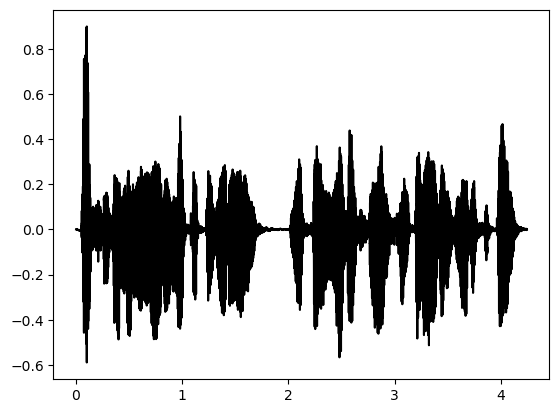

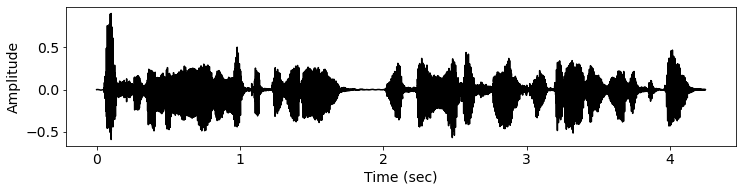

In [4]:
# two ways  
# 1) matplotlib 
time_axis = np.arange(len(y))/fs    # this is a list of time values in seconds, from 0, to len(y)/fs
plt.plot(time_axis,y, color = "black") 

# 2) phonlab
phon.display_wave(y,fs,)
Audio(y,rate=fs)

## c. Make a spectrogram

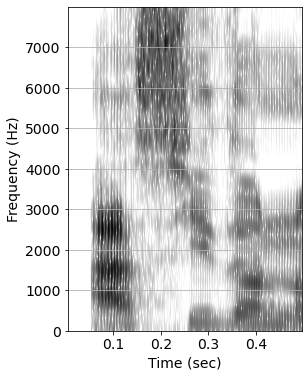

In [5]:
chunk = y[0:int(0.5*fs)]

ret = phon.sgram(chunk,fs,cmap="Grays",band='wb')
Audio(chunk,rate=fs)

## d. Explore some options

Try your hand at tweaking the displays.

* looking at the documentation for [matplotlib.pyplot()](https://matplotlib.org/stable/api/pyplot_summary.html):
    * can you see how to add axis labels to the waveform plot?
    * can you make the waveform a different color?
    * how would you plot a subset of the waveform (say from 1 second to 1.5 seconds?
* looking at the documentation for [phonlab.sgram()](https://phonlab.readthedocs.io/en/latest/acoustphon.html#spectrograms):
    * How would you change the frequency range of the spectrogram?
    * How would you change the color map used in the plot?
    * How would you plot a subset of the spectrogram (say from 1 second to 1.5 seconds)
* extra credit -- how do you change the size of the axis labels on the spectrogram?